# Image Processing SoSe 2026 - Assignment - 02

### Deadline is 30.04.2026 at 11:55 a.m.

#### Students: Fabio & Julius

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

# Exercise 1 - 5 Points
Implement the `rgb_to_hsv` and `hsv_to_rgb` functions. Don't use any color conversion functions from a library.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def rgb_to_hsv(srcimg):
    """
    Converts the numpy array `img` from RGB to the HSV.
    """

    image = np.copy(srcimg)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            r = image[x, y, 0]
            g = image[x, y, 1]
            b = image[x, y, 2]

            mx = max(r, g, b)
            mn = min(r, g, b)
            h = s = v = mx

            d = mx - mn
            s = 0 if mx == 0 else d / mx

            if mx == mn:
                h = 0
            elif mx == r:
                h = (g - b) / d
            elif mx == g:
                h = (b - r) / d + 2
            elif mx == b:
                h = (r - g) / d + 4

            h *= 60
            if h < 0:
                h += 360

            image[x, y, 0] = h
            image[x, y, 1] = s
            image[x, y, 2] = v

    return image

In [3]:
def hsv_to_rgb(srcimg):
    """
    Converts the numpy array `img` from HSV to the RGB.
    """

    image = np.copy(srcimg)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            h = image[x, y, 0]
            s = image[x, y, 1]
            v = image[x, y, 2]

            if h > 1:
                h = (h % 360) / 360.0
            # jetzt h in [0,1)
            h *= 6.0
            c = v * s
            w = c * (1 - abs((h % 2) - 1))
            m = v - c

            if 0 <= h < 1:
                rp, gp, bp = c, w, 0
            elif 1 <= h < 2:
                rp, gp, bp = w, c, 0
            elif 2 <= h < 3:
                rp, gp, bp = 0, c, w
            elif 3 <= h < 4:
                rp, gp, bp = 0, w, c
            elif 4 <= h < 5:
                rp, gp, bp = w, 0, c
            else:  # 5 <= h < 6
                rp, gp, bp = c, 0, w

            image[x, y, 0] = rp + m
            image[x, y, 1] = gp + m
            image[x, y, 2] = bp + m

    return image

Plot the saturation channel of the cat image

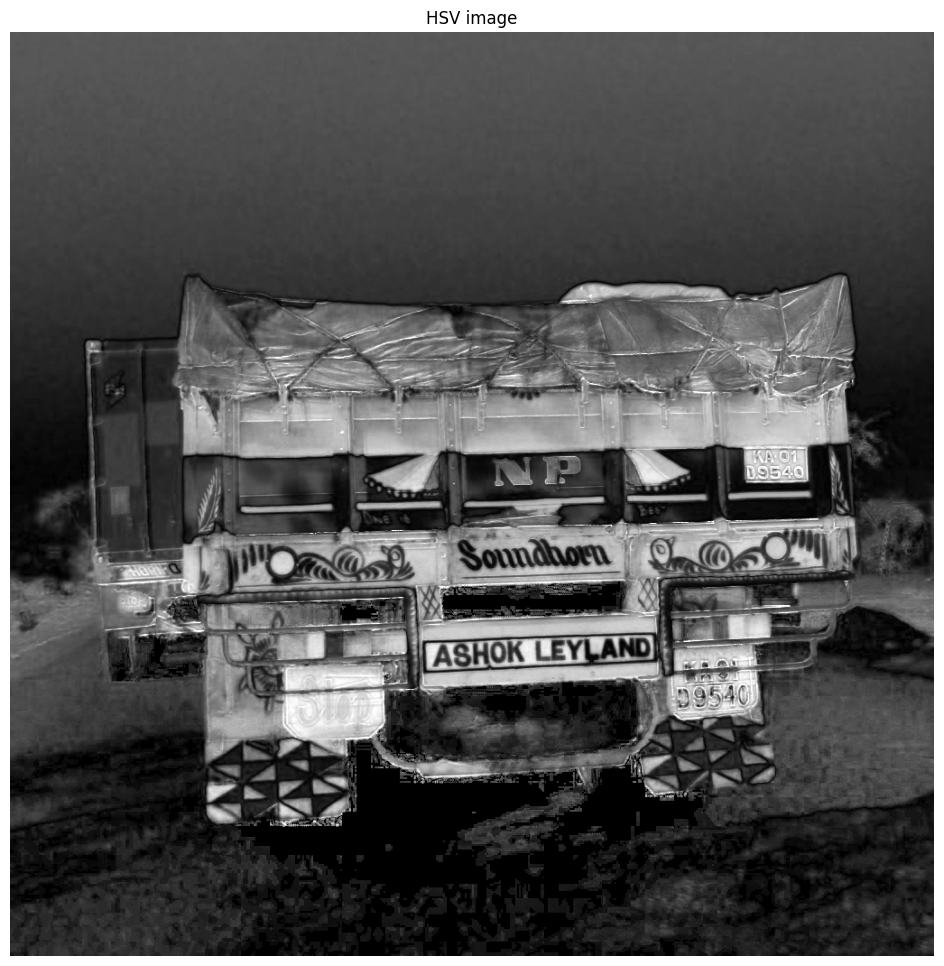

In [4]:
# display the plots inside the notebook
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pylab
pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

img = mpimg.imread('imgs/02-truck.jpeg' , )
img = img / 255.

img_as_hsv = rgb_to_hsv(img)

plt.imshow(img_as_hsv[:,:,1], cmap='gray')
plt.title('HSV image')
plt.axis('off')
plt.show()

Increase the saturation by a factor of 2, convert it back to RGB and plot the result.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8313725490196078..1.0].


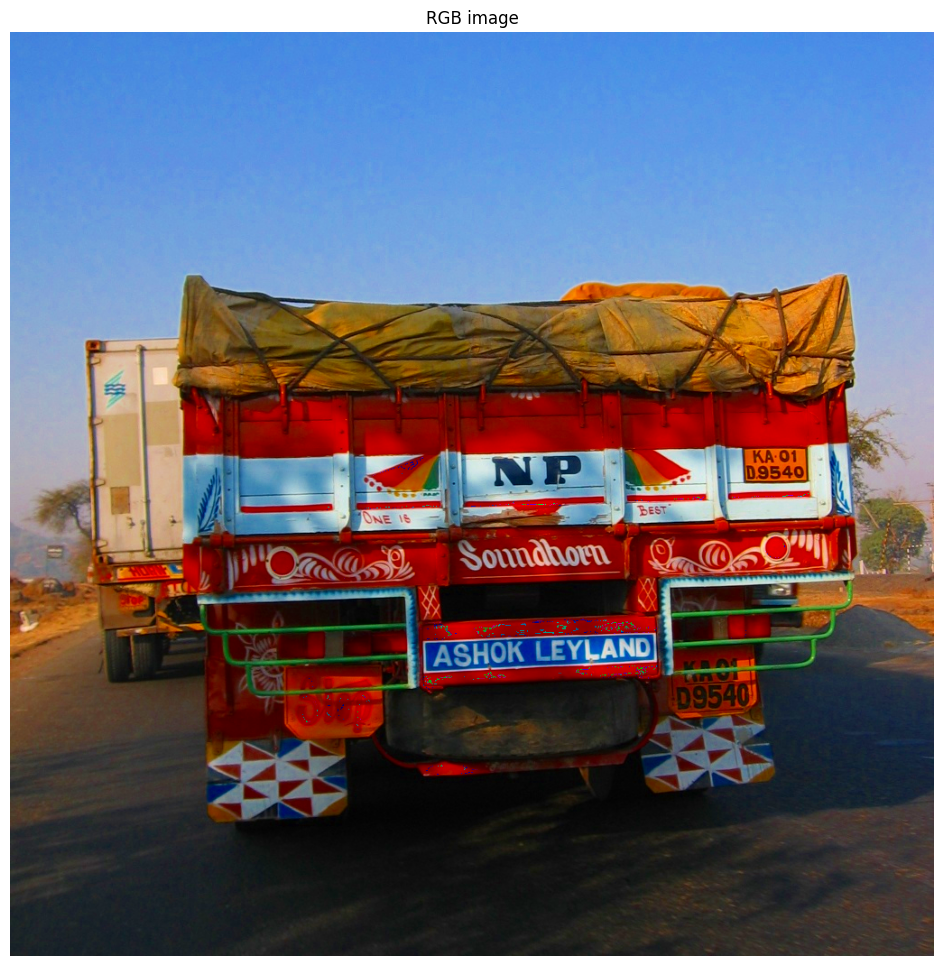

In [5]:
img_as_hsv[:,:,1] = 2 * img_as_hsv[:,:,1]
img_as_rgb = hsv_to_rgb(img_as_hsv)

plt.imshow(img_as_rgb)
plt.title('RGB image')
plt.axis('off')
plt.show()

# Exercise 2 - 5 Points
Write a function to transform an RGB-image into the YUV color space, and another function to transform the image back (from YUV to RGB).

In [6]:
# we use the BT709 matrices here
# see https://en.wikipedia.org/wiki/YCbCr#ITU-R_BT.709_conversion
rgb_to_ycbcr = np.array([[0.2126, 0.7152, 0.0722],
                         [-0.1146, -0.3854, 0.5],
                         [0.5, -0.4542, -0.0458]])

def rgb_to_yuv(srcimg):
    image = np.copy(srcimg)

    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            r = image[x, y, 0]
            g = image[x, y, 1]
            b = image[x, y, 2]

            yuv = rgb_to_ycbcr @ np.array([r, g, b])
            image[x, y] = yuv

    
    return image

Now do the following: Transform the image from the previous task into the YUV-color space. Write a function to perform a 4:2:0 chroma-subsampling, i.e. the chroma channels are for 4 pixels the same, and apply this function. Transform the resulting image back into the RGB-space

(nutze Mittelwert von allen 4 Pixeln, nicht nur 2)

In [7]:
def chroma_subsampling(srcimg):
    image = np.copy(srcimg)
    for x in range(0, image.shape[0], 2):
        for y in range(0, image.shape[1], 2):
            sub_chroma = 0
            for sx in range(2):
                for sy in range(2):
                    sub_chroma += image[x + sx, y + sy]
            for sx in range(2):
                for sy in range(2):
                    image[x + sx, y + sy] = sub_chroma / 4
    return image

ycbcr_to_rgb = np.array([[1, 0, 1.5748],
                         [1, -0.1873, -0.4681],
                         [1, 1.8556, 0]])

def yuv_to_rgb(srcimg):
    image = np.copy(srcimg)
    return image

 Plot the original image and the 4:2:0 chroma-subsampled images. Do you see differences and if so, where?

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30758235294117653..0.9452974509803921].


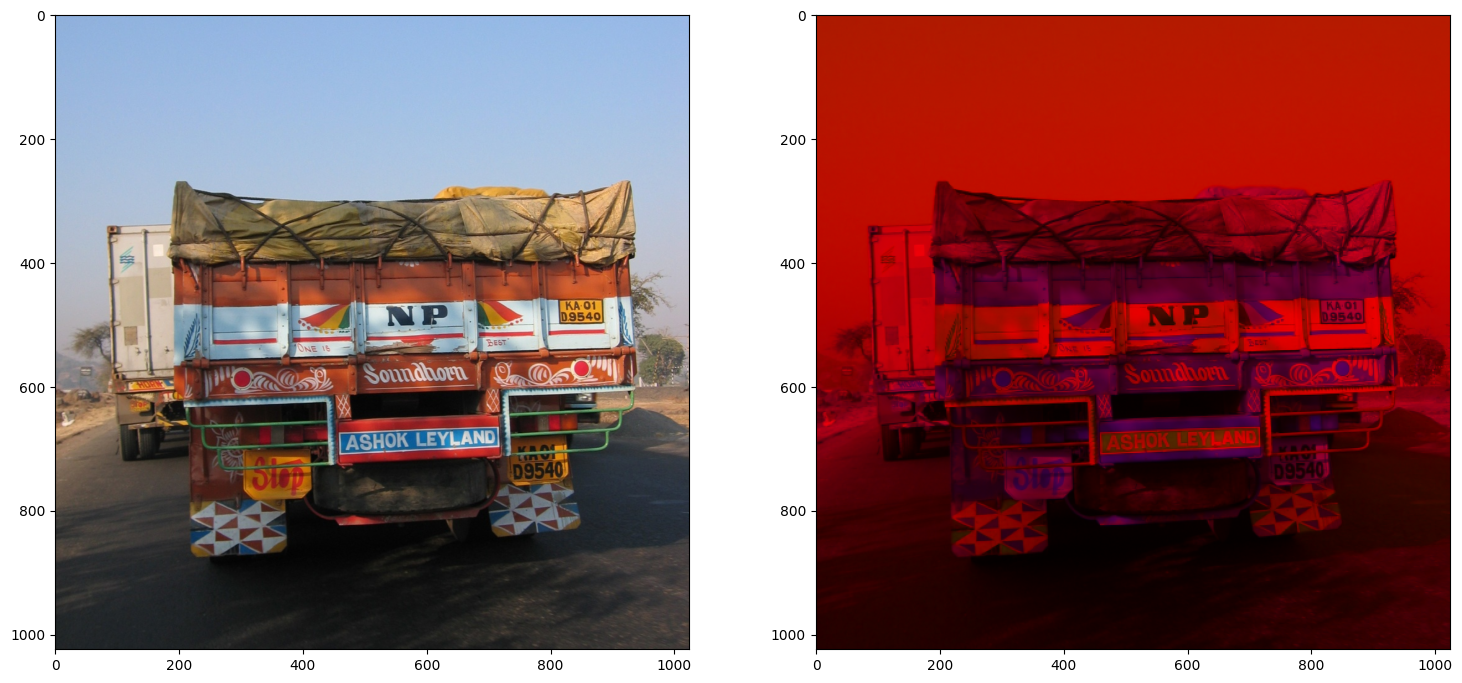

In [8]:
img_yuv = rgb_to_yuv(img)
img_yuv_420 = chroma_subsampling(img_yuv)
img_rgb = yuv_to_rgb(img_yuv_420)

plt.figure(figsize=(18, 12))
plt.subplot(121)
plt.imshow(img)
plt.subplot(122)
plt.imshow(img_rgb)
plt.show()